In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import imageio
import os

In [2]:
data_df = pd.read_csv("gdf_clustered.csv")
gdf = gpd.GeoDataFrame(
    data_df, geometry=gpd.points_from_xy(data_df["x"], data_df["y"]), crs="EPSG:4326"
)
clusters = pd.Categorical(gdf["cluster_kmeans"], categories=set(gdf["cluster_kmeans"]), ordered=False)
gdf["cluster_kmeans"] = clusters
gdf.head()

,Unnamed: 0,I_CUADRO,OBJECTID,Join_Count,TARGET_FID,ID_HILLO,ID_SON,ANYO,FOLIO,SEXO,...,Unnamed: 69,day,week,month,year,dayofyear,FD,FHD,geometry,cluster_kmeans
0,22,2010-08-30,20,1,236,250,6904,0,929,mujer,...,NaN,30,35,8,2010,242,0,1,POINT (-111.0155 29.13418),0
1,23,2010-09-01,25,1,241,255,6927,0,976,hombre,...,NaN,1,35,9,2010,244,0,1,POINT (-110.96435 29.13623),0
2,24,2010-09-02,26,1,242,256,6928,0,977,mujer,...,NaN,2,35,9,2010,245,1,0,POINT (-110.96647 29.1374),1
3,25,2010-09-02,27,1,243,257,6929,0,978,hombre,...,NaN,2,35,9,2010,245,1,0,POINT (-110.96414 29.13722),0
4,26,2010-09-02,33,1,249,262,6944,0,997,hombre,...,NaN,2,35,9,2010,245,1,0,POINT (-110.9677 29.12675),0


In [3]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2706 entries, 0 to 2705
Data columns (total 80 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Unnamed: 0      2706 non-null   int64   
 1   I_CUADRO        2706 non-null   object  
 2   OBJECTID        2706 non-null   int64   
 3   Join_Count      2706 non-null   int64   
 4   TARGET_FID      2706 non-null   int64   
 5   ID_HILLO        2706 non-null   int64   
 6   ID_SON          2706 non-null   int64   
 7   ANYO            2706 non-null   int64   
 8   FOLIO           2706 non-null   int64   
 9   SEXO            2706 non-null   object  
 10  EDAD            2706 non-null   int64   
 11  D_H_            2705 non-null   object  
 12  U_NOTIFICA      2705 non-null   object  
 13  J_N_            2705 non-null   float64 
 14  DOMICILIO       2706 non-null   object  
 15  COLONIA         2665 non-null   object  
 16  LOCALIDAD       2706 non-null   object  
 17  MUNICI

In [4]:
type = []
for _, row in gdf.iterrows():
    if row["FHD"] == 1:
        type.append("FHD")
    else:
        type.append("FD")

gdf["tipo"] = type
gdf.head()

,Unnamed: 0,I_CUADRO,OBJECTID,Join_Count,TARGET_FID,ID_HILLO,ID_SON,ANYO,FOLIO,SEXO,...,day,week,month,year,dayofyear,FD,FHD,geometry,cluster_kmeans,tipo
0,22,2010-08-30,20,1,236,250,6904,0,929,mujer,...,30,35,8,2010,242,0,1,POINT (-111.0155 29.13418),0,FHD
1,23,2010-09-01,25,1,241,255,6927,0,976,hombre,...,1,35,9,2010,244,0,1,POINT (-110.96435 29.13623),0,FHD
2,24,2010-09-02,26,1,242,256,6928,0,977,mujer,...,2,35,9,2010,245,1,0,POINT (-110.96647 29.1374),1,FD
3,25,2010-09-02,27,1,243,257,6929,0,978,hombre,...,2,35,9,2010,245,1,0,POINT (-110.96414 29.13722),0,FD
4,26,2010-09-02,33,1,249,262,6944,0,997,hombre,...,2,35,9,2010,245,1,0,POINT (-110.9677 29.12675),0,FD


In [5]:
weeks = gdf["week"].unique()
weeks = np.arange(weeks.min(), weeks.max()+1)
weeks

array([35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52])

In [26]:
folder = "./mapa_tipo_semanal"
weekly_typed_map_images = []

In [ ]:
for i, week_num in enumerate(weeks):
    if i == 0:
        week_gdf = gdf[gdf["week"] == weeks[0]]
    else:
        week_gdf = gpd.GeoDataFrame( pd.concat( [week_gdf, gdf[gdf["week"] == weeks[i]]], ignore_index=True) )

    fig, ax = plt.subplots(figsize=(10, 10))
    week_gdf.plot(ax=ax, figsize=(8, 8), alpha=0.5, column="tipo", legend=True, cmap='Set1_r', markersize=8)
    ax.set_title(f"Casos por Tipo - Semana {week_num}")
    ax.set_xlim(-111.1, -110.85)
    ax.set_ylim(28.97, 29.25)

    cx.add_basemap(ax=ax, crs="EPSG:4326", source=cx.providers.CartoDB.Voyager)

    filename = f'mapa_tipo_semanal_{week_num}.png'
    plt.savefig(os.path.join(folder,filename))
    weekly_typed_map_images.append(imageio.imread(os.path.join(folder,filename)))

imageio.mimsave(os.path.join(folder,'mapa_tipo_semanal.gif'), weekly_typed_map_images, fps=3)

## Animation for Type FD

In [6]:
gdf_fd = gdf[gdf["tipo"] == "FD"]
gdf_fd.head()

,Unnamed: 0,I_CUADRO,OBJECTID,Join_Count,TARGET_FID,ID_HILLO,ID_SON,ANYO,FOLIO,SEXO,...,day,week,month,year,dayofyear,FD,FHD,geometry,cluster_kmeans,tipo
2,24,2010-09-02,26,1,242,256,6928,0,977,mujer,...,2,35,9,2010,245,1,0,POINT (-110.96647 29.1374),1,FD
3,25,2010-09-02,27,1,243,257,6929,0,978,hombre,...,2,35,9,2010,245,1,0,POINT (-110.96414 29.13722),0,FD
4,26,2010-09-02,33,1,249,262,6944,0,997,hombre,...,2,35,9,2010,245,1,0,POINT (-110.9677 29.12675),0,FD
5,27,2010-09-03,28,1,244,258,6930,0,979,mujer,...,3,35,9,2010,246,1,0,POINT (-110.97021 29.13076),0,FD
6,28,2010-09-03,32,1,248,263,6945,0,998,hombre,...,3,35,9,2010,246,1,0,POINT (-110.96329 29.12872),0,FD


In [7]:
weeks = gdf_fd["week"].unique()
weeks = np.arange(weeks.min(), weeks.max()+1)
weeks

array([35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52])

In [10]:
folder_fd = "./mapa_tipo_FD_semanal"
weekly_type_fd_map_images = []

In [ ]:
for i, week_num in enumerate(weeks):
    if i == 0:
        week_gdf = gdf_fd[gdf_fd["week"] == weeks[0]]
    else:
        week_gdf = gpd.GeoDataFrame( pd.concat( [week_gdf, gdf_fd[gdf_fd["week"] == weeks[i]]], ignore_index=True) )

    fig, ax = plt.subplots(figsize=(10, 10))
    week_gdf.plot(ax=ax, figsize=(8, 8), alpha=0.5, column="tipo", legend=True, cmap='Set1_r', markersize=8)
    ax.set_title(f'Casos de Tipo "FD" - Semana {week_num}')
    ax.set_xlim(-111.1, -110.85)
    ax.set_ylim(28.97, 29.25)

    cx.add_basemap(ax=ax, crs="EPSG:4326", source=cx.providers.CartoDB.Voyager)

    filename = f'mapa_tipo_FD_semanal_{week_num}.png'
    plt.savefig(os.path.join(folder_fd,filename))
    weekly_type_fd_map_images.append(imageio.imread(os.path.join(folder_fd,filename)))

imageio.mimsave(os.path.join(folder_fd,'mapa_cluster_0_semanal.gif'), weekly_type_fd_map_images, fps=3)

## Animation for Type FHD

In [5]:
gdf_fhd = gdf[gdf["tipo"] == "FHD"]
gdf_fhd.head()

,Unnamed: 0,I_CUADRO,OBJECTID,Join_Count,TARGET_FID,ID_HILLO,ID_SON,ANYO,FOLIO,SEXO,...,day,week,month,year,dayofyear,FD,FHD,geometry,cluster_kmeans,tipo
0,22,2010-08-30,20,1,236,250,6904,0,929,mujer,...,30,35,8,2010,242,0,1,POINT (-111.0155 29.13418),0,FHD
1,23,2010-09-01,25,1,241,255,6927,0,976,hombre,...,1,35,9,2010,244,0,1,POINT (-110.96435 29.13623),0,FHD
16,38,2010-09-06,22,1,238,252,6921,0,966,hombre,...,6,36,9,2010,249,0,1,POINT (-110.96343 29.14891),0,FHD
17,39,2010-09-06,30,1,246,260,6942,0,995,mujer,...,6,36,9,2010,249,0,1,POINT (-110.9634 29.12683),0,FHD
19,41,2010-09-06,41,1,257,271,6991,0,1047,mujer,...,6,36,9,2010,249,0,1,POINT (-110.96569 29.12749),0,FHD


In [13]:
weeks = gdf_fhd["week"].unique()
weeks = np.arange(weeks.min(), weeks.max()+1)
weeks

array([35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52])

In [25]:
folder_fhd = "./mapa_tipo_FHD_semanal"
weekly_type_fhd_map_images = []

In [ ]:
for i, week_num in enumerate(weeks):
    if i == 0:
        week_gdf = gdf_fhd[gdf_fhd["week"] == weeks[0]]
    else:
        week_gdf = gpd.GeoDataFrame( pd.concat( [week_gdf, gdf_fhd[gdf_fhd["week"] == weeks[i]]], ignore_index=True) )

    fig, ax = plt.subplots(figsize=(10, 10))
    week_gdf.plot(ax=ax, figsize=(8, 8), alpha=0.5, column="tipo", legend=True, cmap='RdGy', markersize=8)
    ax.set_title(f'Casos de Tipo "FHD" - Semana {week_num}')
    ax.set_xlim(-111.1, -110.85)
    ax.set_ylim(28.97, 29.25)

    cx.add_basemap(ax=ax, crs="EPSG:4326", source=cx.providers.CartoDB.Voyager)

    filename = f'mapa_tipo_FHD_semanal_{week_num}.png'
    plt.savefig(os.path.join(folder_fhd,filename))
    weekly_type_fhd_map_images.append(imageio.imread(os.path.join(folder_fhd,filename)))

imageio.mimsave(os.path.join(folder_fhd,'mapa_tipo_FHD_semanal.gif'), weekly_type_fhd_map_images, fps=3)

## Animation of Counts

In [32]:
# Spike count by day

# Actual counts:
gdf_counts = pd.DataFrame(gdf.groupby("dayofyear")["FD_FHD"].count())
gdf_counts["week"] = gdf.groupby("dayofyear")["week"].mean().astype("int")
gdf_counts["FD"] = gdf.groupby("dayofyear")["FD"].sum()
gdf_counts["FHD"] = gdf.groupby("dayofyear")["FHD"].sum()
# Cumulative total:
gdf_counts["FD_FHD_cumsum"] = gdf_counts["FD_FHD"].cumsum()
gdf_counts["FD_cumsum"] = gdf_counts["FD"].cumsum()
gdf_counts["FHD_cumsum"] = gdf_counts["FHD"].cumsum()
# Rolling mean:
gdf_counts["FD_FHD_mean"] = gdf_counts["FD_FHD"].rolling(7).mean()
gdf_counts["FD_mean"] = gdf_counts["FD"].rolling(7).mean()
gdf_counts["FHD_mean"] = gdf_counts["FHD"].rolling(7).mean()

gdf_counts.tail()

,FD_FHD,week,FD,FHD,FD_FHD_cumsum,FD_cumsum,FHD_cumsum,FD_FHD_mean,FD_mean,FHD_mean
dayofyear,,,,,,,,,,
354,1,51,1,0,2699,2313,386,2.428571,1.714286,0.714286
358,1,51,0,1,2700,2313,387,2.428571,1.571429,0.857143
361,1,52,1,0,2701,2314,387,2.285714,1.571429,0.714286
362,2,52,1,1,2703,2315,388,2.285714,1.428571,0.857143
365,3,52,2,1,2706,2317,389,2.428571,1.428571,1.000000


In [55]:
weeks = gdf_counts["week"].unique()
weeks = np.arange(weeks.min(), weeks.max()+1)
weeks

array([35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52])

In [56]:
folder_conteo = "./conteo_tipo_semanal"
weekly_count_type_images = []

/tmp/ipykernel_5192/2048312531.py:21: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  weekly_count_type_images.append(imageio.imread(os.path.join(folder_conteo,filename)))


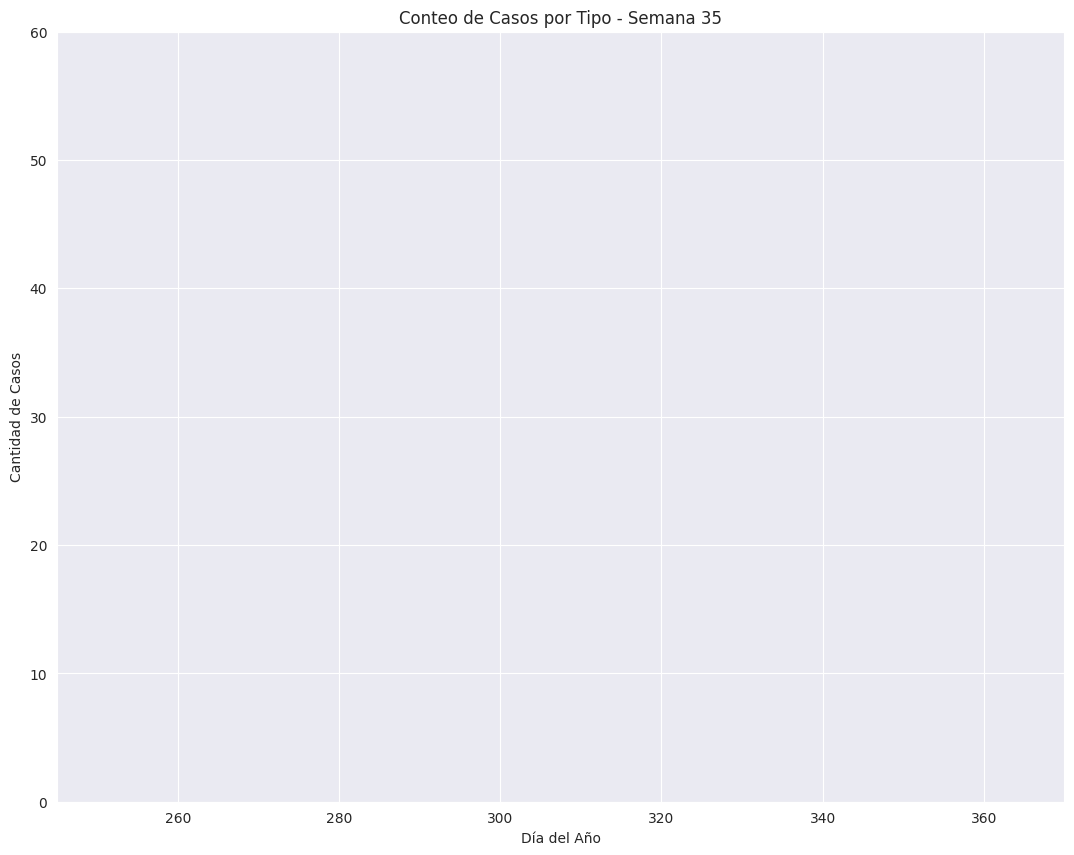

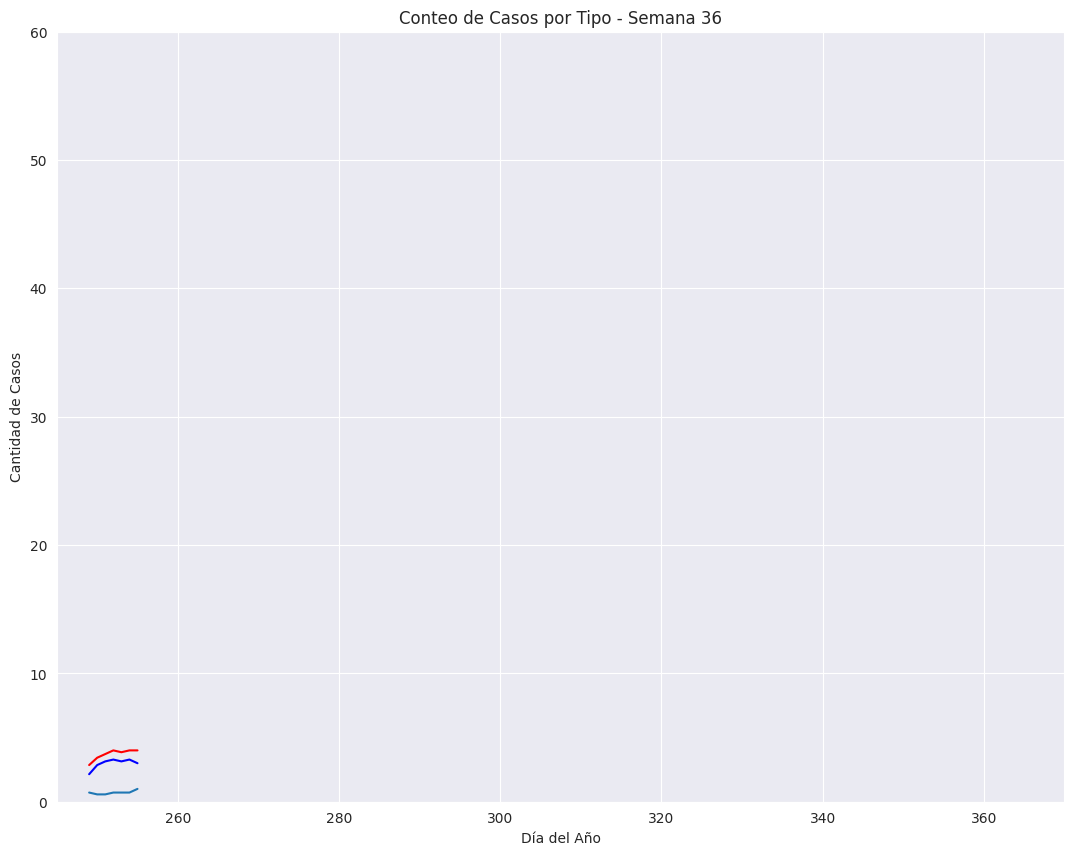

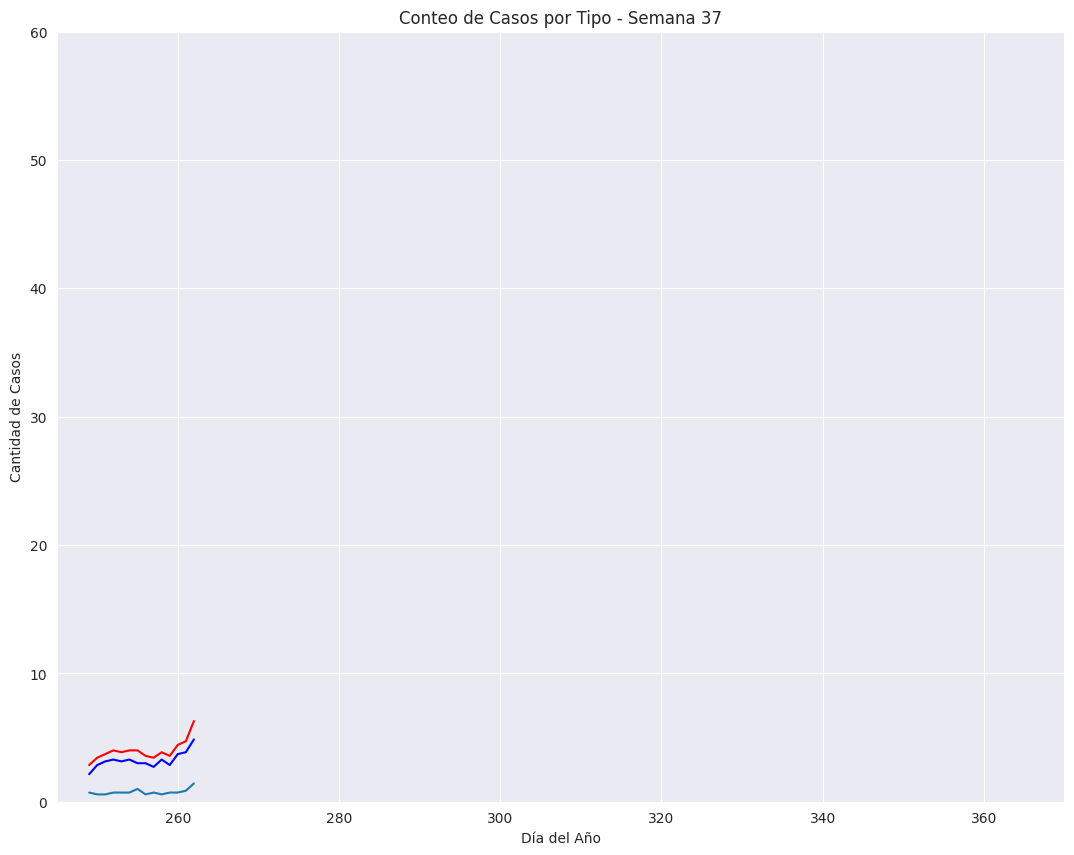

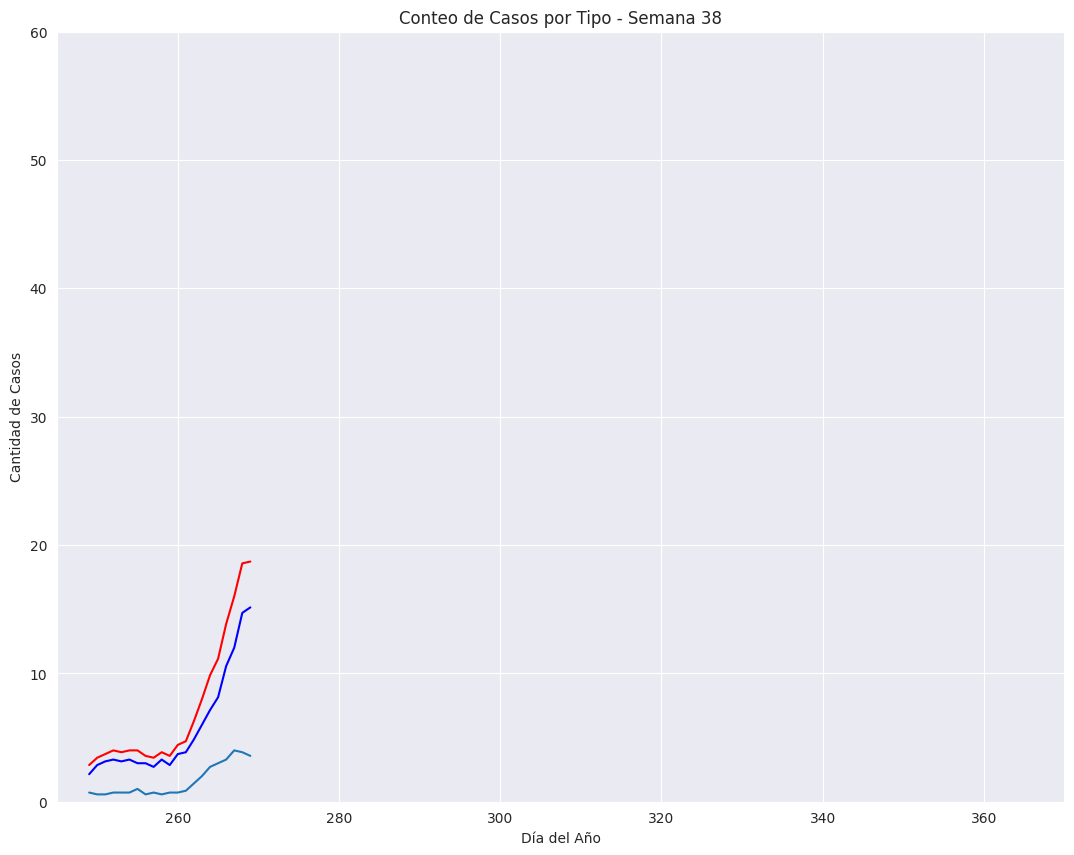

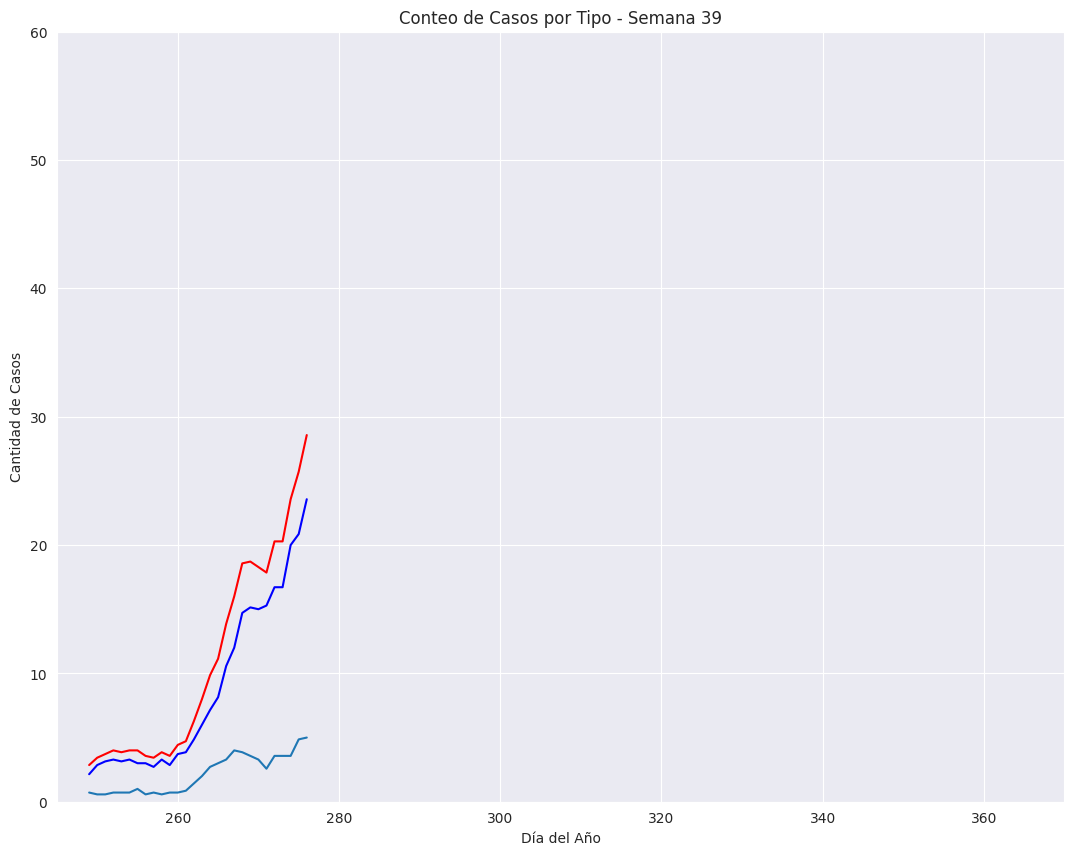

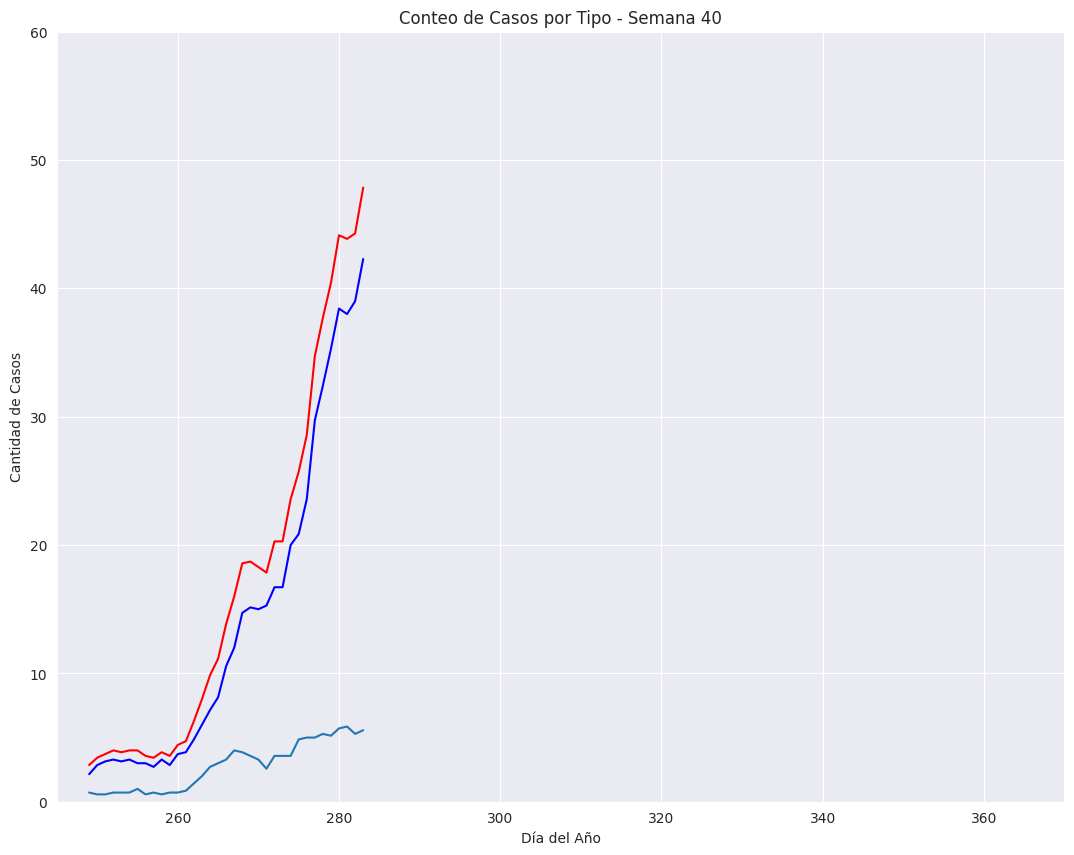

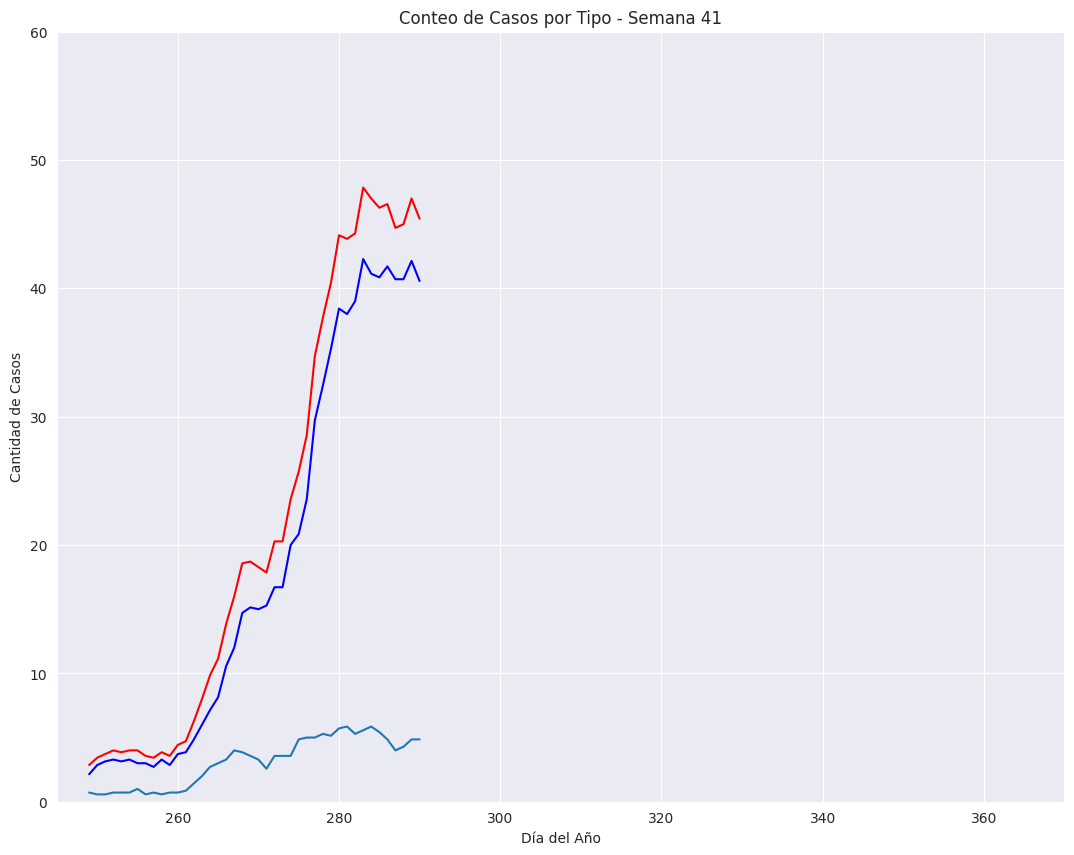

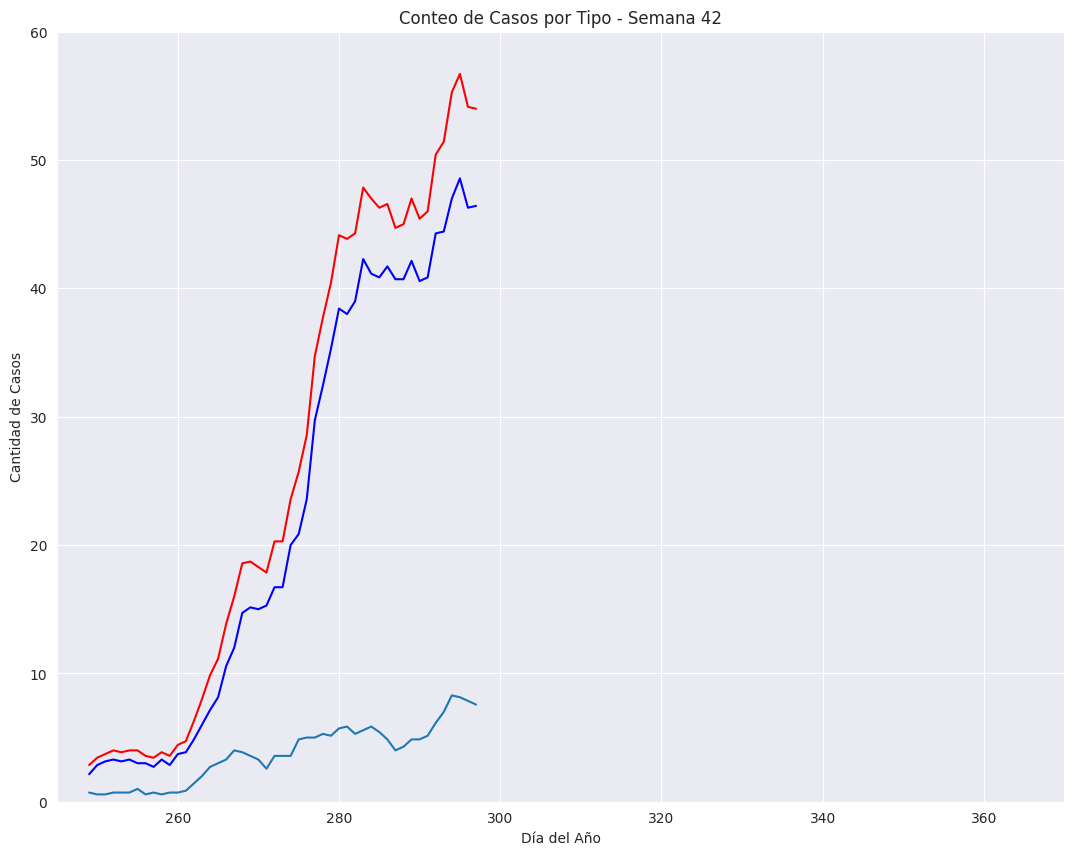

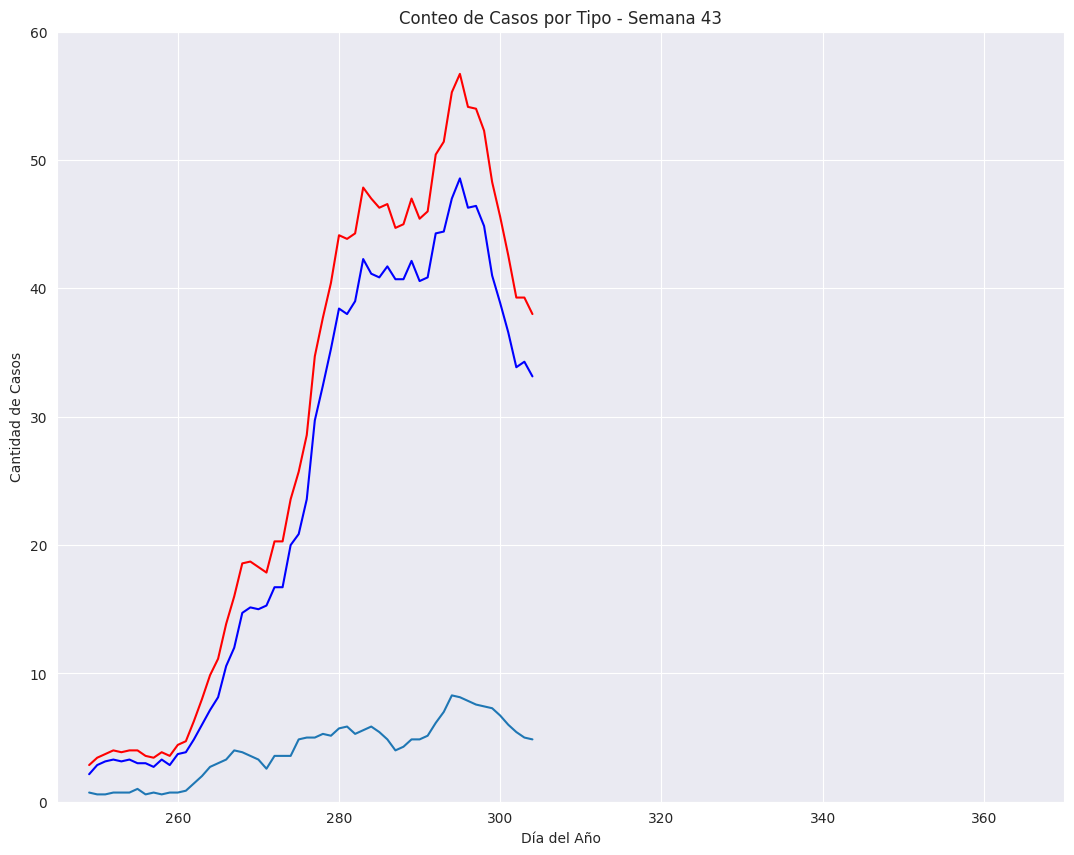

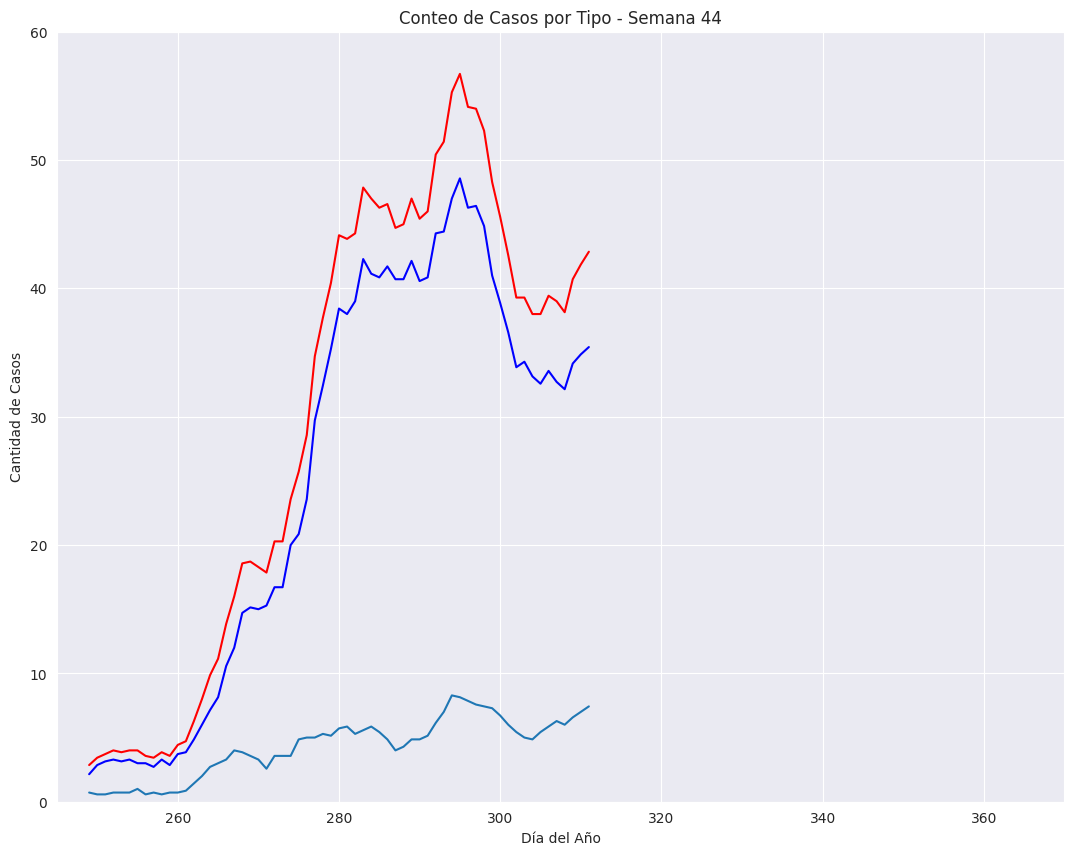

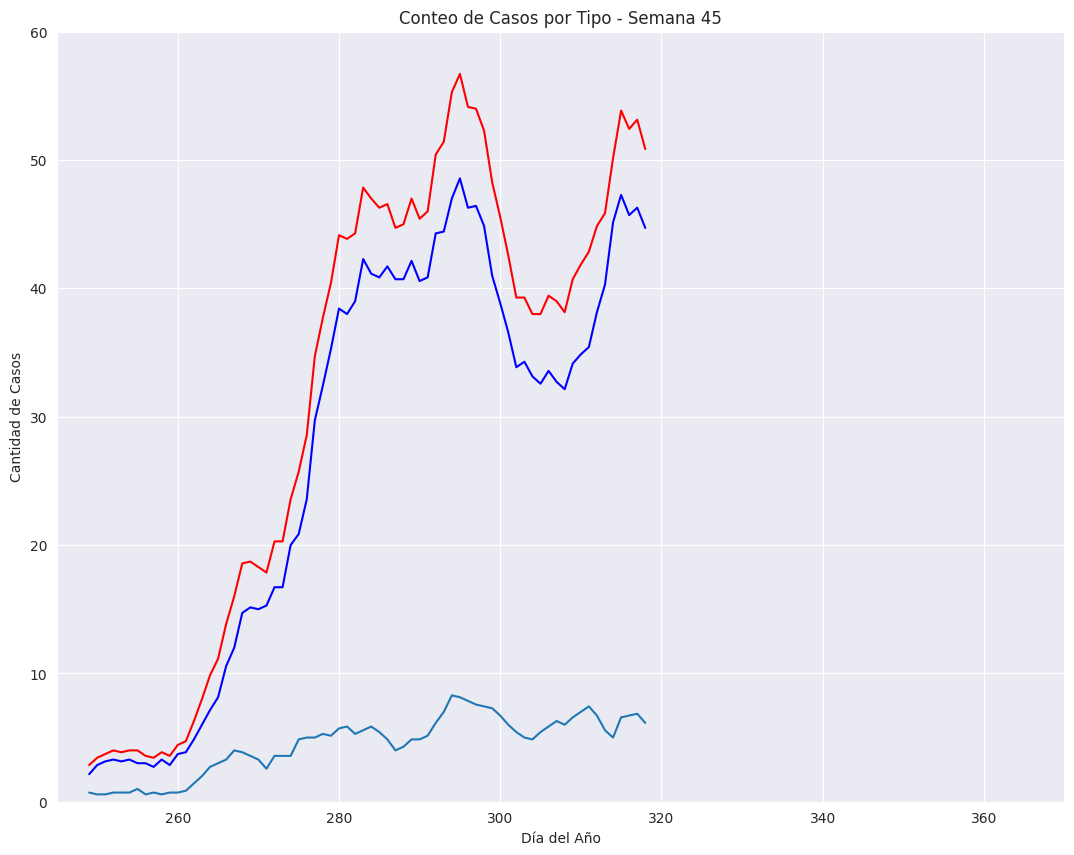

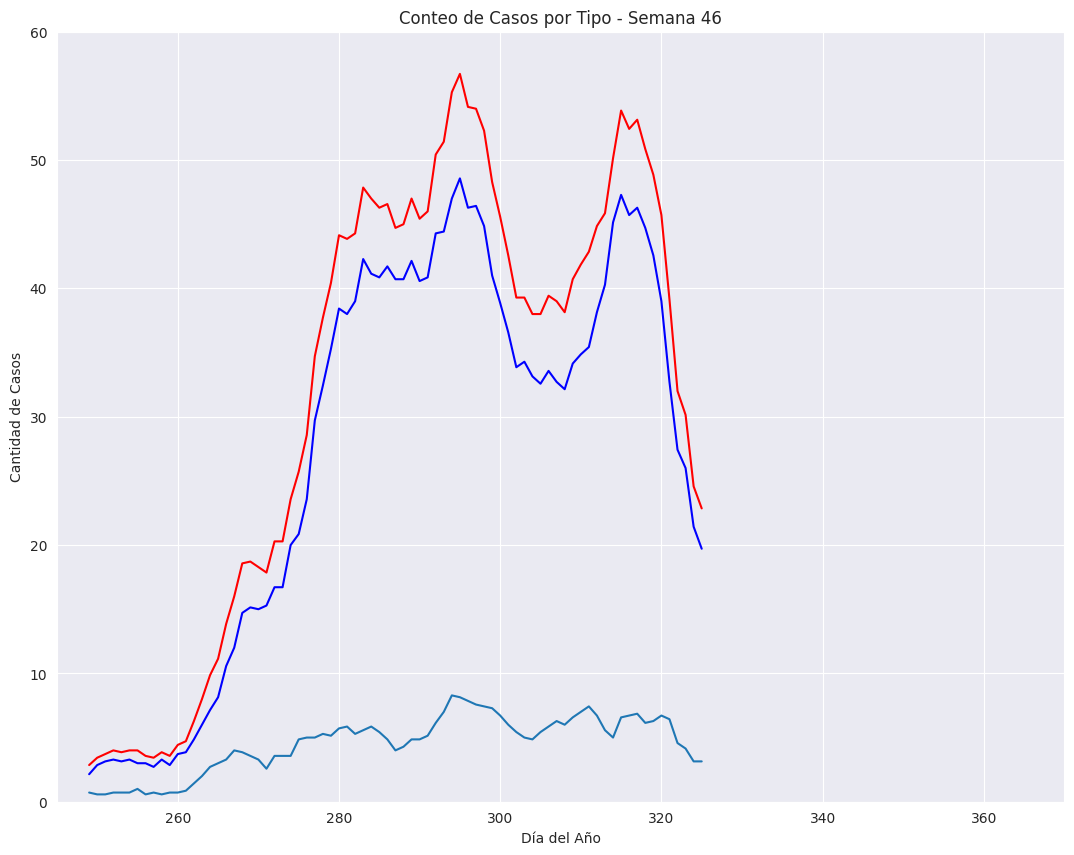

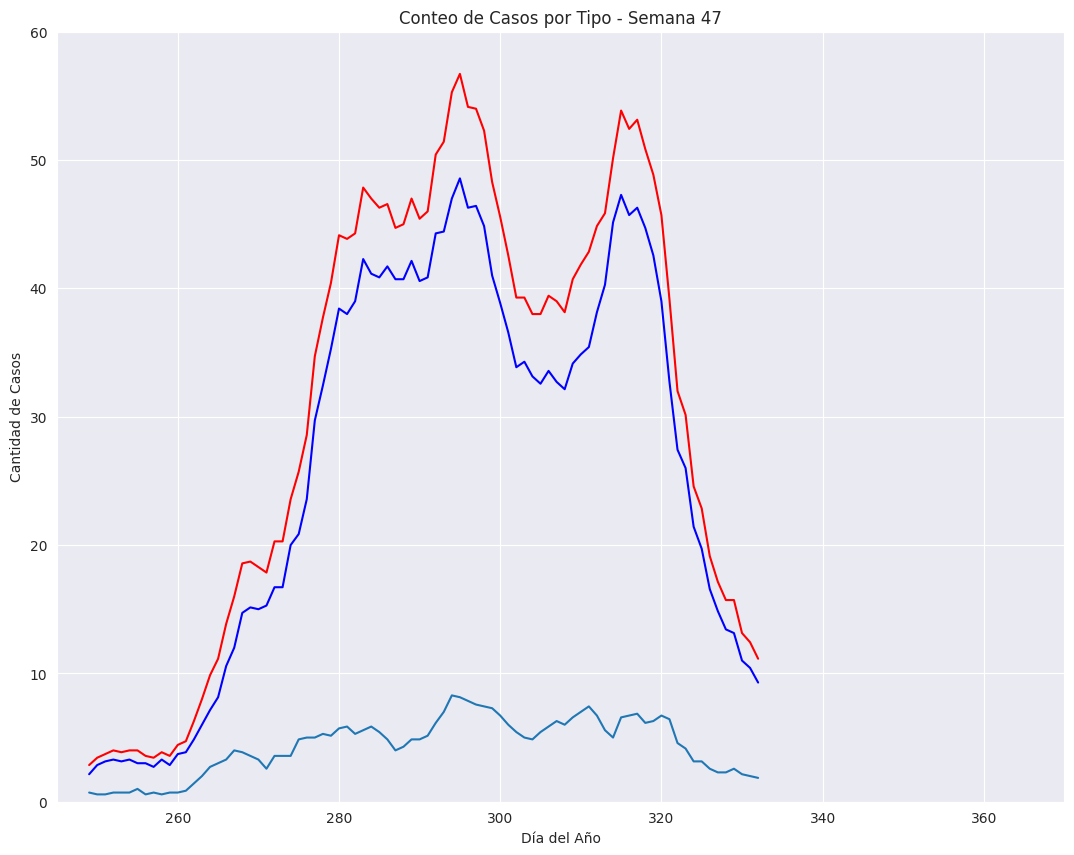

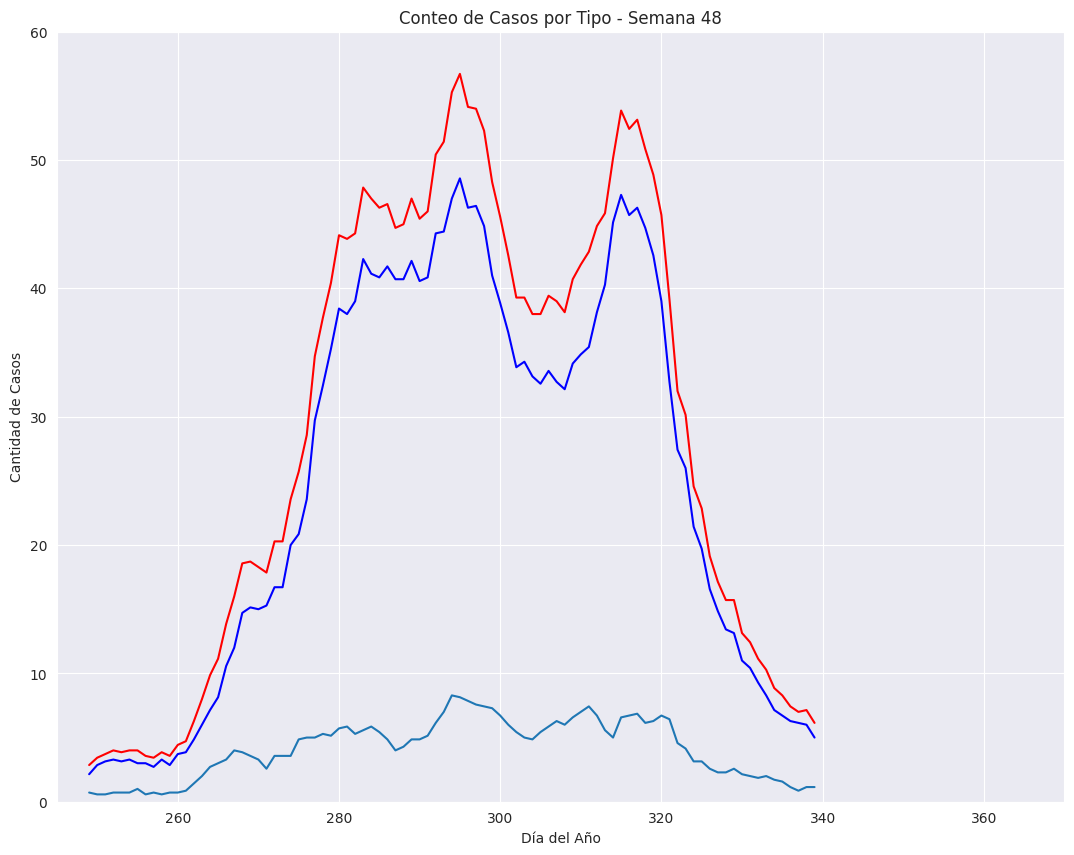

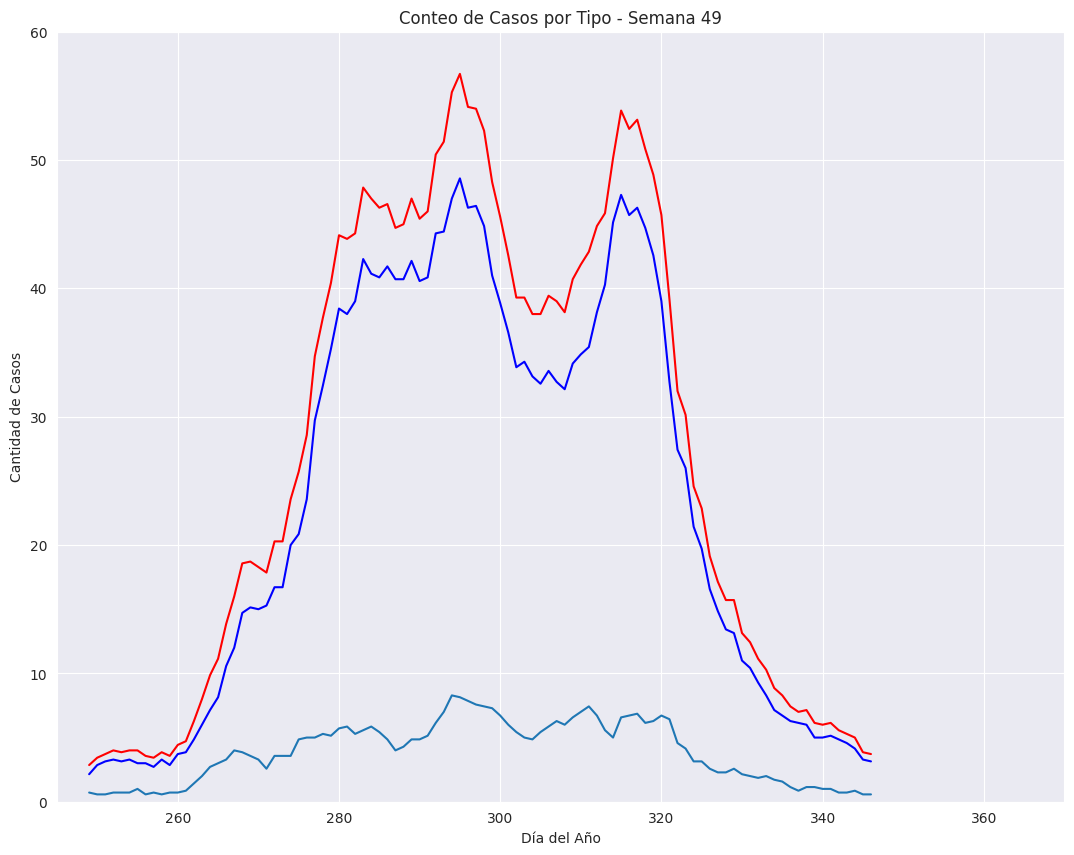

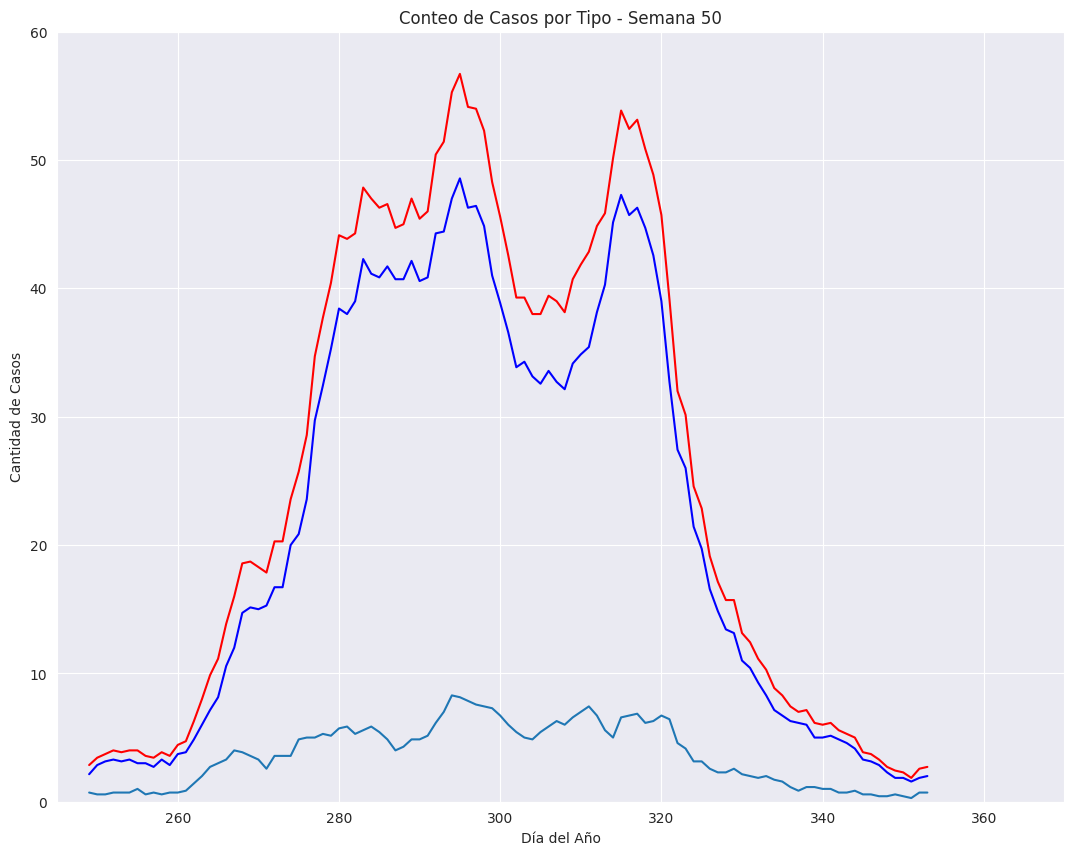

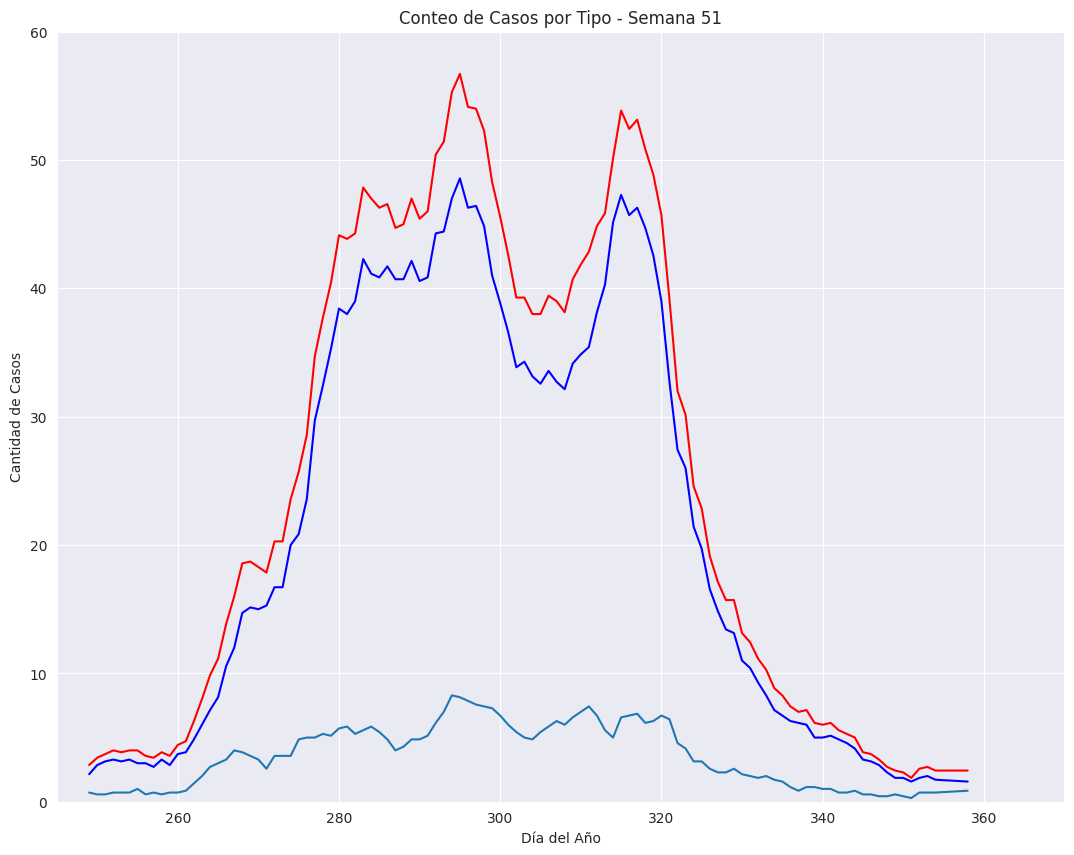

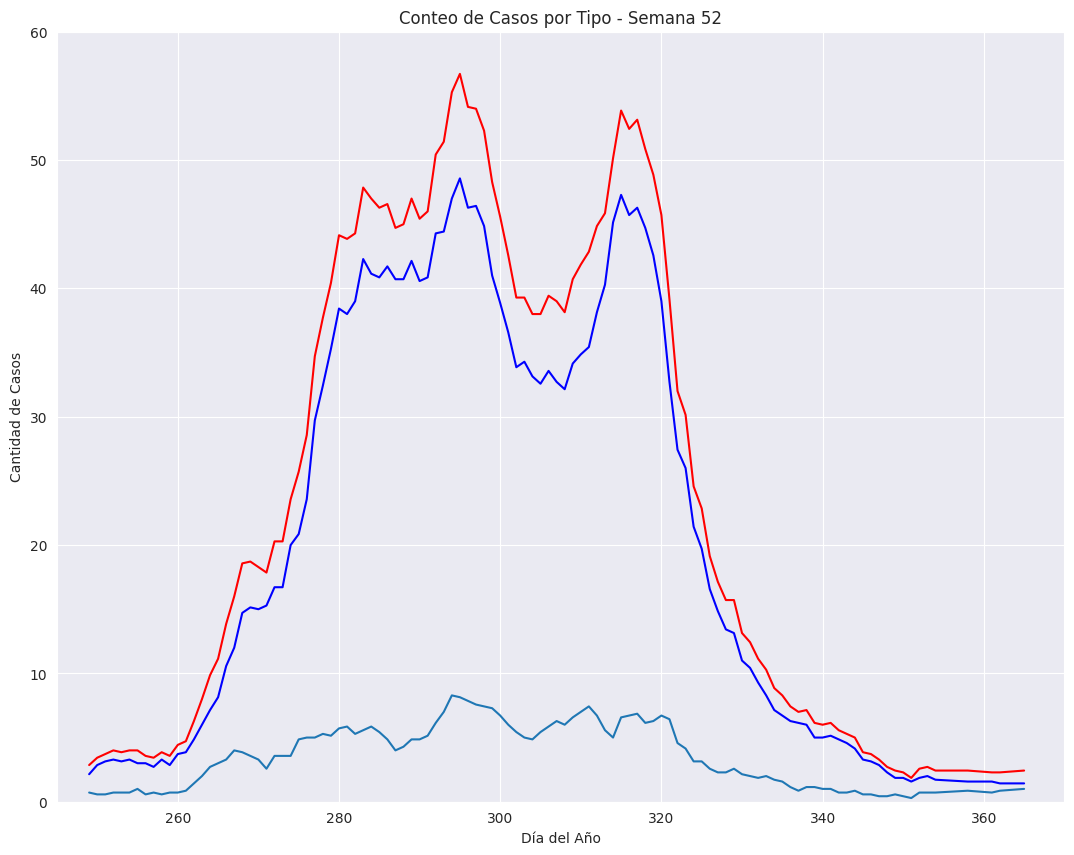

In [57]:
for i, week_num in enumerate(weeks):
    if i == 0:
        week_gdf = gdf_counts[gdf_counts["week"] == weeks[0]]
    else:
        week_gdf = pd.concat( [week_gdf, gdf_counts[gdf_counts["week"] == weeks[i]]], ignore_index=False)

    fig, ax = plt.subplots(figsize=(13, 10))

    ax.plot(week_gdf.index, week_gdf["FD_FHD_mean"], color="red", label="Total")
    ax.plot(week_gdf.index, week_gdf["FD_mean"], color="blue", label="Total")
    ax.plot(week_gdf.index, week_gdf["FHD_mean"])

    ax.set_title(f'Conteo de Casos por Tipo - Semana {week_num}')
    ax.set_xlabel("Día del Año")
    ax.set_ylabel("Cantidad de Casos")
    ax.set_xlim(245, 370)
    ax.set_ylim(0, 60)

    filename = f'mapa_conteo_tipo_semanal_{week_num}.png'
    plt.savefig(os.path.join(folder_conteo,filename))
    weekly_count_type_images.append(imageio.imread(os.path.join(folder_conteo,filename)))

imageio.mimsave(os.path.join(folder_conteo,'conteo_tipo_semanal.gif'), weekly_count_type_images, fps=3)

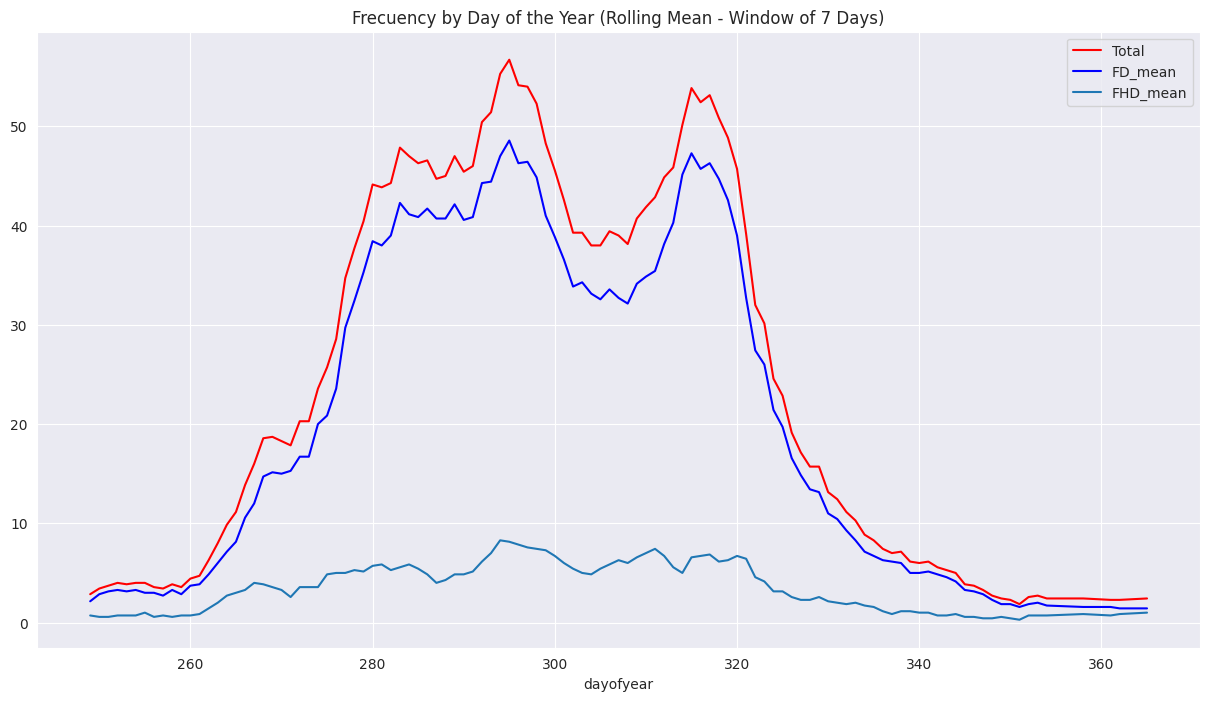

In [30]:
fig, ax = plt.subplots(figsize=(15,8))

gdf_counts["FD_FHD_mean"].plot(ax=ax, color="red", label="Total")
gdf_counts["FD_mean"].plot(ax=ax, color="blue")
gdf_counts["FHD_mean"].plot(ax=ax)

plt.title("Frecuency by Day of the Year (Rolling Mean - Window of 7 Days)")
plt.legend()
plt.show()
